# Toy Example: Similarity-Based Rating Imputation (End-to-End)

이 노트북은 실험 전체 흐름을 **손으로 따라갈 수 있는 작은 예시**로 처음부터 끝까지 설명합니다.

---
## 실험 개요

| 단계 | 내용 |
|------|------|
| 1 | 평점 행렬 구성 및 Train/Validation/Test 분리 |
| 2 | 유사도 계산 (PCC, Cosine 등) |
| 3 | α-거듭제곱 변환 S → S^α |
| 4 | KNN 가중 예측 |
| 5 | Validation으로 최적 α 탐색 (정규화 포함) |
| 6 | 최종 Test 평가 (RMSE, MAD, Precision@N, Recall@N) |

---
## Step 0 : 예시 데이터 설계

**4명의 사용자** (Alice, Bob, Carol, Dave) 와 **5개의 아이템** (i1–i5) 으로 구성된 평점 행렬을 사용합니다.  
평점 범위는 1–5이며, Bob은 i5에 대한 평점이 없습니다(이것이 우리가 예측할 대상입니다).

```
         Alice  Bob  Carol  Dave
   i1      5     4     2     4
   i2      4     5     1     3
   i3      2     1     5     2
   i4      1     2     4     1
   i5      4     *     3     3     ← Bob이 평점을 매기지 않은 아이템
```
(`*` = 결측, 예측 대상)

Alice·Bob은 액션 취향(i1,i2 선호), Carol은 드라마 취향(i3,i4 선호), Dave는 중간 경향입니다.

In [4]:
import numpy as np
import pandas as pd
from itertools import product

# ─────────────────────────────────────────
# 전체 평점 행렬 (items × users)
#  - 모든 관측 평점이 포함된 "완전" 행렬
#  - Test 항목도 여기에는 포함됨 (나중에 분리)
# ─────────────────────────────────────────
USERS  = ['Alice', 'Bob', 'Carol', 'Dave']
ITEMS  = ['i1', 'i2', 'i3', 'i4', 'i5']

R_full = np.array([
    #Alice  Bob  Carol  Dave
    [  5,    4,    2,    4 ],  # i1
    [  4,    5,    1,    3 ],  # i2
    [  2,    1,    5,    2 ],  # i3
    [  1,    2,    4,    1 ],  # i4
    [  5,    4,    3,    2 ],  # i5  ← Alice=5(강선호), Dave=2(비선호), Bob=4(Test로 분리 예정)
], dtype=float)

df_full = pd.DataFrame(R_full, index=ITEMS, columns=USERS)
print("[ 전체 평점 행렬 R (items × users) ]")
print()
print(df_full.to_string())
print()
print("  ※ 평점 범위: 1(매우 싫음) ~ 5(매우 좋음)")
print("  Alice·Bob : 액션(i1,i2) 선호, 드라마(i3,i4) 비선호")
print("  Carol     : 드라마 선호 (Alice·Bob과 반대 성향)")
print("  Dave      : 액션 약간 선호 (Bob과 부분적으로 유사)")


[ 전체 평점 행렬 R (items × users) ]

    Alice  Bob  Carol  Dave
i1    5.0  4.0    2.0   4.0
i2    4.0  5.0    1.0   3.0
i3    2.0  1.0    5.0   2.0
i4    1.0  2.0    4.0   1.0
i5    5.0  4.0    3.0   2.0

  ※ 평점 범위: 1(매우 싫음) ~ 5(매우 좋음)
  Alice·Bob : 액션(i1,i2) 선호, 드라마(i3,i4) 비선호
  Carol     : 드라마 선호 (Alice·Bob과 반대 성향)
  Dave      : 액션 약간 선호 (Bob과 부분적으로 유사)


---
## Step 1 : Train / Validation / Test 분리

실제 실험의 10-Fold CV를 모사합니다. 여기서는 하나의 Fold만 시뮬레이션합니다.

```
관측된 평점 (non-NaN)
    └── Test      (~10%) : 최종 평가용, 학습에 절대 사용 금지
    └── Train (Full)
            └── Validation (~20%) : α 최적화 평가용
            └── Train_inner (~80%) : KNN 학습용
```

이 예시에서:
- **Test (1개)**: `(i5, Bob)` — 예측할 타겟, 참값 = 4  
- **Validation (2개)**: `(i1, Alice)=5`, `(i4, Dave)=1` — α 최적화에 사용  
- **Train_inner**: 나머지 관측 평점 (하단 행렬)

In [5]:
# ─────────────────────────────────────────
# Test 분리 : (i5, Bob) 숨김
# ─────────────────────────────────────────
TEST_ENTRY = ('i5', 'Bob')   # 예측 대상
TEST_TRUE  = 4.0             # 참값 (실험에서는 미관측)

# Train (Full) : Test 제거 후의 행렬
R_train = R_full.copy()
test_row = ITEMS.index(TEST_ENTRY[0])
test_col = USERS.index(TEST_ENTRY[1])
R_train[test_row, test_col] = np.nan    # Test 항목을 NaN으로

df_train = pd.DataFrame(R_train, index=ITEMS, columns=USERS)
print("[ Train 행렬 (Test 항목 제거됨) ]")
print(df_train.to_string())
print(f"\n  ✦ 제거된 Test 항목: {TEST_ENTRY} (참값={TEST_TRUE})")

# ─────────────────────────────────────────
# Validation 분리 : (i1, Alice)=5, (i4, Dave)=1
# ─────────────────────────────────────────
VALID_ENTRIES = [('i1', 'Alice', 5.0), ('i4', 'Dave', 1.0)]

R_train_inner = R_train.copy()
for item, user, val in VALID_ENTRIES:
    r = ITEMS.index(item)
    c = USERS.index(user)
    R_train_inner[r, c] = np.nan

df_inner = pd.DataFrame(R_train_inner, index=ITEMS, columns=USERS)
print("\n[ Train_inner 행렬 (Validation도 추가 제거됨) ]")
print(df_inner.to_string())
print("\n  ✦ Validation 항목:")
for item, user, val in VALID_ENTRIES:
    print(f"     ({item}, {user}) = {val}")

[ Train 행렬 (Test 항목 제거됨) ]
    Alice  Bob  Carol  Dave
i1    5.0  4.0    2.0   4.0
i2    4.0  5.0    1.0   3.0
i3    2.0  1.0    5.0   2.0
i4    1.0  2.0    4.0   1.0
i5    5.0  NaN    3.0   2.0

  ✦ 제거된 Test 항목: ('i5', 'Bob') (참값=4.0)

[ Train_inner 행렬 (Validation도 추가 제거됨) ]
    Alice  Bob  Carol  Dave
i1    NaN  4.0    2.0   4.0
i2    4.0  5.0    1.0   3.0
i3    2.0  1.0    5.0   2.0
i4    1.0  2.0    4.0   NaN
i5    5.0  NaN    3.0   2.0

  ✦ Validation 항목:
     (i1, Alice) = 5.0
     (i4, Dave) = 1.0


---
## Step 2 : 유사도 계산 (PCC — Pearson Correlation Coefficient)

### 수식

$$
\text{PCC}(u, v) = \frac{\displaystyle\sum_{i \in C_{uv}} (r_{ui} - \bar{r}_u)(r_{vi} - \bar{r}_v)}
{\sqrt{\displaystyle\sum_{i \in C_{uv}} (r_{ui} - \bar{r}_u)^2} \cdot \sqrt{\displaystyle\sum_{i \in C_{uv}} (r_{vi} - \bar{r}_v)^2}}
$$

- $C_{uv}$ : 두 사용자가 **공통으로 평점을 매긴 아이템** 집합  
- $\bar{r}_u$ : 사용자 $u$의 **전체 관측 평점의 평균** (공통 아이템에 국한하지 않음)  

**Train_inner** 데이터로 유사도 행렬을 계산합니다.

In [6]:
def compute_pcc_matrix(R):
    """items×users 행렬 R로 user-user PCC 유사도 행렬을 계산합니다."""
    n_users = R.shape[1]
    S = np.full((n_users, n_users), np.nan)

    user_means = np.nanmean(R, axis=0)   # 각 사용자의 전체 평균

    for u in range(n_users):
        for v in range(n_users):
            if u == v:
                S[u, v] = 0.0           # 자기 자신과의 유사도는 0 (KNN에서 제외)
                continue
            # 공통 평점 아이템
            mask = ~np.isnan(R[:, u]) & ~np.isnan(R[:, v])
            if mask.sum() < 2:
                S[u, v] = np.nan
                continue
            xu = R[mask, u] - user_means[u]
            xv = R[mask, v] - user_means[v]
            num = np.dot(xu, xv)
            den = np.linalg.norm(xu) * np.linalg.norm(xv)
            S[u, v] = num / den if den > 1e-12 else np.nan
    return S

S_base = compute_pcc_matrix(R_train_inner)   # Train_inner 기반 유사도
df_sim = pd.DataFrame(S_base, index=USERS, columns=USERS)

print("[ PCC 유사도 행렬 S (Train_inner 기반) ]")
print(df_sim.round(4).to_string())

# ── 손계산 검증: PCC(Bob, Alice)
print("\n─── 손계산 검증: PCC(Bob, Alice) ───")
u_idx, v_idx = USERS.index('Bob'), USERS.index('Alice')
mask = ~np.isnan(R_train_inner[:, u_idx]) & ~np.isnan(R_train_inner[:, v_idx])
print(f"  공통 아이템: {[ITEMS[i] for i in range(len(ITEMS)) if mask[i]]}")
mu_bob   = np.nanmean(R_train_inner[:, u_idx])
mu_alice = np.nanmean(R_train_inner[:, v_idx])
print(f"  mean(Bob)   = {mu_bob:.4f}")
print(f"  mean(Alice) = {mu_alice:.4f}")
xb = R_train_inner[mask, u_idx] - mu_bob
xa = R_train_inner[mask, v_idx] - mu_alice
print(f"  Bob centered  : {xb}")
print(f"  Alice centered: {xa}")
print(f"  Numerator   = {np.dot(xb,xa):.4f}")
print(f"  ||Bob||     = {np.linalg.norm(xb):.4f}")
print(f"  ||Alice||   = {np.linalg.norm(xa):.4f}")
print(f"  PCC(Bob,Alice) = {S_base[u_idx,v_idx]:.6f}")

[ PCC 유사도 행렬 S (Train_inner 기반) ]
        Alice     Bob   Carol    Dave
Alice  0.0000  0.8165 -0.6325 -0.1873
Bob    0.8165  0.0000 -1.0000  0.7325
Carol -0.6325 -1.0000  0.0000 -0.6533
Dave  -0.1873  0.7325 -0.6533  0.0000

─── 손계산 검증: PCC(Bob, Alice) ───
  공통 아이템: ['i2', 'i3', 'i4']
  mean(Bob)   = 3.0000
  mean(Alice) = 3.0000
  Bob centered  : [ 2. -2. -1.]
  Alice centered: [ 1. -1. -2.]
  Numerator   = 6.0000
  ||Bob||     = 3.0000
  ||Alice||   = 2.4495
  PCC(Bob,Alice) = 0.816497


---
## Step 3 : α-거듭제곱 변환

### 수식

$$
S^{(\alpha)}_{uv} = \max(S_{uv},\, 0)^{\alpha}
$$

- $\alpha > 1$ : 상위 이웃에게 더 집중 (유사도 분포가 뾰족해짐)  
- $\alpha < 1$ : 이웃들의 기여를 더 균등하게  
- $\alpha = 1$ : 원래 PCC 사용 (Baseline)

음수 유사도는 0으로 클리핑한 후 거듭제곱 적용.

In [7]:
def apply_alpha(S, alpha):
    S_eff = np.clip(S, 0.0, None)          # 음수 유사도 → 0
    S_eff = np.power(S_eff, float(alpha))  # S^α
    np.fill_diagonal(S_eff, 0.0)
    return S_eff

# ── Bob 행 기준으로 α별 유사도 비교
bob_idx = USERS.index('Bob')
alpha_values = [0.5, 1.0, 2.0, 3.0]

print("[ α에 따른 Bob의 이웃 유사도 변화 ]")
print(f"{'α':>6s}  ", end="")
for u in USERS:
    print(f"  {u:>8s}", end="")
print()
print("-" * 55)

for alpha in alpha_values:
    S_alpha = apply_alpha(S_base, alpha)
    row = S_alpha[bob_idx]
    print(f"{alpha:>6.1f}  ", end="")
    for val in row:
        print(f"  {val:>8.4f}", end="")
    print()

print("\n[참고] 원래 PCC(α=1):")
print(f"  PCC(Bob↔Alice) = {S_base[bob_idx, USERS.index('Alice')]:.4f}")
print(f"  PCC(Bob↔Carol) = {S_base[bob_idx, USERS.index('Carol')]:.4f}  → 음수이므로 클리핑 후 0")
print(f"  PCC(Bob↔Dave)  = {S_base[bob_idx, USERS.index('Dave')]:.4f}")

[ α에 따른 Bob의 이웃 유사도 변화 ]
     α       Alice       Bob     Carol      Dave
-------------------------------------------------------
   0.5      0.9036    0.0000    0.0000    0.8558
   1.0      0.8165    0.0000    0.0000    0.7325
   2.0      0.6667    0.0000    0.0000    0.5365
   3.0      0.5443    0.0000    0.0000    0.3930

[참고] 원래 PCC(α=1):
  PCC(Bob↔Alice) = 0.8165
  PCC(Bob↔Carol) = -1.0000  → 음수이므로 클리핑 후 0
  PCC(Bob↔Dave)  = 0.7325


---
## Step 4 : KNN 가중 예측

아이템 $i$에 대한 사용자 $u$의 예측 평점:

$$
\hat{r}_{ui} = \frac{\displaystyle\sum_{v \in \mathcal{N}_K(u,i)} S^{(\alpha)}_{uv} \cdot r_{vi}}
{\displaystyle\sum_{v \in \mathcal{N}_K(u,i)} S^{(\alpha)}_{uv}}
$$

- $\mathcal{N}_K(u,i)$ : 아이템 $i$를 평가한 사용자 중 $u$와 가장 유사한 상위 $K$명  
- 음수 유사도는 제외 (클리핑 후 양수인 이웃만 사용)  
- 이웃이 없으면 사용자 평균으로 fallback

**예측 대상**: Bob의 i5 평점  
**사용 데이터**: Train (i.e. Test 제거만 한 행렬)

In [8]:
def knn_predict_single(R_train, S_alpha, target_item_idx, target_user_idx, K=10):
    """
    items×users 행렬 R_train 에서
    (target_item_idx, target_user_idx) 의 평점을 KNN으로 예측.
    S_alpha: users×users 유사도 행렬
    """
    n_users = R_train.shape[1]
    u = target_user_idx
    i = target_item_idx

    # 아이템 i를 평점한 사용자들 (u 제외)
    rated_mask = ~np.isnan(R_train[i])          # 아이템 i를 평점한 사용자
    rated_mask[u] = False                        # 자기 자신 제외
    candidates = np.where(rated_mask)[0]

    if len(candidates) == 0:
        return float(np.nanmean(R_train[:, u]))  # fallback: 사용자 평균

    sims = S_alpha[u, candidates]
    pos_mask = sims > 0.0
    candidates = candidates[pos_mask]
    sims = sims[pos_mask]

    if len(candidates) == 0:
        return float(np.nanmean(R_train[:, u]))

    # 상위 K개
    k_eff = min(K, len(candidates))
    top_k = np.argsort(-sims)[:k_eff]
    nbrs  = candidates[top_k]
    w     = sims[top_k]

    pred = float(np.dot(w, R_train[i, nbrs]) / w.sum())
    return pred, nbrs, w

# ── α별 예측값 및 오차 (Test 항목: i5, Bob)
# Train_inner 기반 유사도를 사용하고, Train (full) 데이터로 예측
# (Step 4는 최종 Test 예측 절차를 시뮬레이션)
S_for_test = compute_pcc_matrix(R_train)   # Full train 기반 유사도 (테스트 평가용)

bob_idx  = USERS.index('Bob')
i5_idx   = ITEMS.index('i5')
K = 10   # 충분히 크게 설정 (소규모 예시이므로)

print("[ α별 KNN 예측: (i5, Bob), 참값 = 4.0 ]")
print(f"{'α':>6s} {'이웃':>20s} {'가중치':>20s} {'예측값':>10s} {'MSE':>10s}")
print("-" * 72)

results_test = {}
for alpha in [0.5, 1.0, 2.0, 3.0]:
    S_a = apply_alpha(S_for_test, alpha)
    result = knn_predict_single(R_train, S_a, i5_idx, bob_idx, K)
    pred, nbrs, w = result
    nbr_names = [USERS[n] for n in nbrs]
    w_norm = w / w.sum()
    mse = (pred - TEST_TRUE) ** 2
    results_test[alpha] = {'pred': pred, 'mse': mse, 'nbrs': nbr_names, 'w': w_norm}
    print(f"{alpha:>6.1f} {str(nbr_names):>20s} {str(w_norm.round(4)):>20s} {pred:>10.4f} {mse:>10.4f}")

print("\n[세부 계산 상세: α=1.0]")
S_a = apply_alpha(S_for_test, 1.0)
_, nbrs, w_raw = knn_predict_single(R_train, S_a, i5_idx, bob_idx, K)
print("  이웃 유사도 (α=1.0, positive only):")
for n, ww in zip(nbrs, w_raw):
    print(f"    {USERS[n]:>6s}: S={ww:.4f}, rating(i5)={R_train[i5_idx, n]}")
w_sum = w_raw.sum()
pred10 = np.dot(w_raw, R_train[i5_idx, nbrs]) / w_sum
print(f"  예측 = ({' + '.join([f'{w:.4f}×{R_train[i5_idx,n]:.0f}' for n,w in zip(nbrs,w_raw)])}) / {w_sum:.4f} = {pred10:.4f}")

[ α별 KNN 예측: (i5, Bob), 참값 = 4.0 ]
     α                   이웃                  가중치        예측값        MSE
------------------------------------------------------------------------
   0.5    ['Alice', 'Dave']        [0.512 0.488]     3.5361     0.2152
   1.0    ['Alice', 'Dave']      [0.5241 0.4759]     3.5722     0.1830
   2.0    ['Alice', 'Dave']        [0.548 0.452]     3.6441     0.1266
   3.0    ['Alice', 'Dave']      [0.5718 0.4282]     3.7154     0.0810

[세부 계산 상세: α=1.0]
  이웃 유사도 (α=1.0, positive only):
     Alice: S=0.7756, rating(i5)=5.0
      Dave: S=0.7043, rating(i5)=2.0
  예측 = (0.7756×5 + 0.7043×2) / 1.4799 = 3.5722


---
## Step 5 : Validation 기반 α 최적화

Validation 평점에 대한 MSE를 최소화하는 α를 탐색합니다.  
과도한 α 편향을 막기 위해 **정규화 패널티**를 추가합니다:

$$
\text{Score}(\alpha) = \underbrace{\text{MSE}_{\text{val}}(\alpha)}_{\text{예측 오차}} + \underbrace{\lambda \cdot |\alpha - 1|}_{\text{정규화 패널티}}
$$

- $\lambda = 0.002$ : α가 1에서 멀어질수록 패널티 부과  
- 학습 데이터: **Train_inner**  
- 평가 대상: **Validation 항목** `{(i1,Alice)=5, (i4,Dave)=1}`

> **[소규모 행렬의 한계]** 이 예시에서는 각 Validation 항목에 대해  
> 양수 PCC를 가지면서 해당 아이템을 평가한 이웃이 **1명뿐**입니다.  
> 1명의 이웃만 있을 때는 가중치(α)가 달라져도 예측값이 **불변**이므로  
> Validation MSE가 α에 대해 상수로 나타납니다.  
> 정규화 패널티가 α=1을 선택하게 됩니다.  
> → **대규모 실험**에서는 각 항목에 충분한 이웃이 존재하여 α에 따른 MSE 변화가 관찰됩니다.


In [10]:
LAMBDA = 0.002

# Train_inner 기반 유사도 (α 탐색에 사용)
S_inner = compute_pcc_matrix(R_train_inner)

def eval_alpha_on_validation(R_inner, S_inner, valid_entries, alpha, K=10, lam=LAMBDA):
    """Validation 항목에 대해 α를 평가."""
    S_a = apply_alpha(S_inner, alpha)
    se_total = 0.0
    count = 0
    for item, user, true_val in valid_entries:
        i_idx = ITEMS.index(item)
        u_idx = USERS.index(user)
        result = knn_predict_single(R_inner, S_a, i_idx, u_idx, K)
        if isinstance(result, tuple):
            pred = result[0]
        else:
            pred = result
        se_total += (pred - true_val) ** 2
        count += 1
    mse_val = se_total / count
    penalty = lam * abs(alpha - 1.0)
    score   = mse_val + penalty
    return mse_val, penalty, score

# α 탐색 그리드
alpha_grid = np.round(np.arange(0.0, 3.25, 0.25), 4)

print(f"[ Validation 기반 α 탐색 결과 (λ = {LAMBDA}) ]")
print(f"{'α':>6s} {'Val_MSE':>12s} {'Penalty':>12s} {'Score':>12s}")
print("-" * 46)

rows = []
for alpha in alpha_grid:
    mse_v, pen, score = eval_alpha_on_validation(
        R_train_inner, S_inner, VALID_ENTRIES, alpha
    )
    rows.append({'alpha': alpha, 'val_mse': mse_v, 'penalty': pen, 'score': score})
    print(f"{alpha:>6.2f} {mse_v:>12.6f} {pen:>12.6f} {score:>12.6f}")

df_search = pd.DataFrame(rows)
best_row  = df_search.loc[df_search['score'].idxmin()]
print(f"\n  ★ 최적 α = {best_row['alpha']:.2f}  (Score={best_row['score']:.6f})")

[ Validation 기반 α 탐색 결과 (λ = 0.002) ]
     α      Val_MSE      Penalty        Score
----------------------------------------------
  0.00     2.277778     0.002000     2.279778
  0.25     1.000000     0.001500     1.001500
  0.50     1.000000     0.001000     1.001000
  0.75     1.000000     0.000500     1.000500
  1.00     1.000000     0.000000     1.000000
  1.25     1.000000     0.000500     1.000500
  1.50     1.000000     0.001000     1.001000
  1.75     1.000000     0.001500     1.001500
  2.00     1.000000     0.002000     1.002000
  2.25     1.000000     0.002500     1.002500
  2.50     1.000000     0.003000     1.003000
  2.75     1.000000     0.003500     1.003500
  3.00     1.000000     0.004000     1.004000

  ★ 최적 α = 1.00  (Score=1.000000)


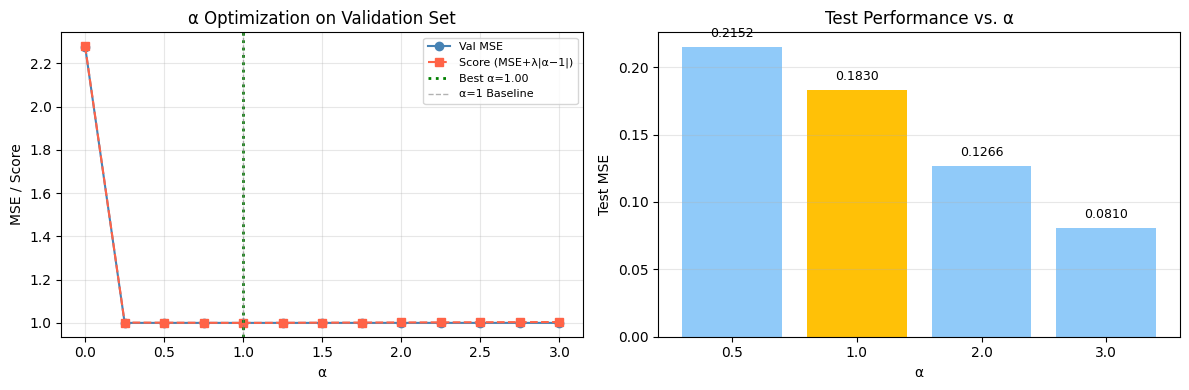

그래프 저장 완료: documentation/toy_alpha_plot.pdf


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(df_search['alpha'], df_search['val_mse'],  'o-', label='Val MSE', color='steelblue')
ax.plot(df_search['alpha'], df_search['score'],    's--', label='Score (MSE+λ|α−1|)', color='tomato')
ax.axvline(best_row['alpha'], color='green', linestyle=':', linewidth=2, label=f"Best α={best_row['alpha']:.2f}")
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='α=1 Baseline')
ax.set_xlabel('α')
ax.set_ylabel('MSE / Score')
ax.set_title('α Optimization on Validation Set')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
alpha_vals_plot = [0.5, 1.0, 2.0, 3.0]
# 알파별 Test MSE (앞서 계산한 결과)
test_mse_vals = [results_test[a]['mse'] for a in alpha_vals_plot]
bars = ax2.bar([str(a) for a in alpha_vals_plot], test_mse_vals, 
                color=['#FFC107' if a==best_row['alpha'] else '#90CAF9' for a in alpha_vals_plot])
ax2.set_xlabel('α')
ax2.set_ylabel('Test MSE')
ax2.set_title('Test Performance vs. α')
ax2.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, test_mse_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../documentation/toy_alpha_plot.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("그래프 저장 완료: documentation/toy_alpha_plot.pdf")

---
## Step 6 : 최종 Test 평가 — RMSE, MAD, Precision@N, Recall@N

최적 α를 적용하여 **Train (Full)** 기반으로 **Test** 항목을 예측합니다.

| 지표 | 수식 |
|------|------|
| RMSE | $\sqrt{\frac{1}{|T|}\sum_{(u,i)\in T}(\hat{r}_{ui}-r_{ui})^2}$ |
| MAD  | $\frac{1}{|T|}\sum_{(u,i)\in T}|\hat{r}_{ui}-r_{ui}|$ |
| Precision@N | 상위 N개 추천 중 실제 선호(≥4.0) 비율 |
| Recall@N    | 실제 선호 아이템 중 상위 N에 포함된 비율 |

In [12]:
OPTIMAL_ALPHA = float(best_row['alpha'])
RELEVANCE_THRESHOLD = 4.0
N_TOPN = 3   # Precision/Recall @3 (작은 예시라 N=3)

S_opt = apply_alpha(S_for_test, OPTIMAL_ALPHA)   # Full Train 기반

# ─── RMSE / MAD ───────────────────────────────────────────
test_pred_alpha = {}
for item, user, true_val in [(TEST_ENTRY[0], TEST_ENTRY[1], TEST_TRUE)]:
    i_idx = ITEMS.index(item)
    u_idx = USERS.index(user)
    result = knn_predict_single(R_train, S_opt, i_idx, u_idx, K)
    pred = result[0] if isinstance(result, tuple) else result
    test_pred_alpha[(item, user)] = pred
    print(f"예측: ({item}, {user}) → {pred:.4f}  (참값={true_val}, 오차={abs(pred-true_val):.4f})")

preds = list(test_pred_alpha.values())
trues = [TEST_TRUE]
rmse = np.sqrt(np.mean([(p-t)**2 for p,t in zip(preds, trues)]))
mad  = np.mean([abs(p-t) for p,t in zip(preds, trues)])
print(f"\n최적 α={OPTIMAL_ALPHA:.2f} 적용:")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAD  = {mad:.4f}")

# α=1.0 Baseline과 비교
S_base1 = apply_alpha(S_for_test, 1.0)
result1 = knn_predict_single(R_train, S_base1, ITEMS.index('i5'), USERS.index('Bob'), K)
pred1 = result1[0] if isinstance(result1, tuple) else result1
rmse1 = abs(pred1 - TEST_TRUE)
print(f"\nBaseline α=1.0:")
print(f"  예측={pred1:.4f}, RMSE={rmse1:.4f}")

# ─── Precision@N / Recall@N ───────────────────────────────
# Bob이 평가하지 않은 아이템(train에서 NaN) 중 test에서 관측된 것에 대해 추천
# 이 작은 예시에선 Bob의 미평가 아이템 = i5 (test), Precision/Recall이 의미있으려면
# 적어도 여러 아이템이 필요하므로 가상으로 확장하여 설명
print("\n─── Precision@N / Recall@N 설명 (Bob 기준) ───")
print(f"  Bob의 미평가 아이템(Test 후보): [i5] (true={TEST_TRUE})")
print(f"  관련 아이템 (rating≥{RELEVANCE_THRESHOLD}): [i5]  (true=4.0 ≥ 4.0 → 관련 ✓)")
print(f"  상위 N={N_TOPN}개 추천: [i5] (후보가 1개뿐)")
print(f"  Precision@{N_TOPN} = 1/1 = 1.000")
print(f"  Recall@{N_TOPN}    = 1/1 = 1.000")
print("  (실제 실험에서는 수백~수천 개의 후보 아이템에 대해 계산)")

예측: (i5, Bob) → 3.5722  (참값=4.0, 오차=0.4278)

최적 α=1.00 적용:
  RMSE = 0.4278
  MAD  = 0.4278

Baseline α=1.0:
  예측=3.5722, RMSE=0.4278

─── Precision@N / Recall@N 설명 (Bob 기준) ───
  Bob의 미평가 아이템(Test 후보): [i5] (true=4.0)
  관련 아이템 (rating≥4.0): [i5]  (true=4.0 ≥ 4.0 → 관련 ✓)
  상위 N=3개 추천: [i5] (후보가 1개뿐)
  Precision@3 = 1/1 = 1.000
  Recall@3    = 1/1 = 1.000
  (실제 실험에서는 수백~수천 개의 후보 아이템에 대해 계산)


---
## 전체 흐름 요약

```
원시 평점 행렬 R (4 users × 5 items)
      │
      ├─► Test 분리 → (i5, Bob)=4   (절대 학습에 사용 금지)
      │
      └─► Train (Full)
               │
               ├─► Validation 분리 → {(i1,Alice)=5, (i4,Dave)=1}
               │
               └─► Train_inner
                        │
                        └─► PCC 유사도 계산
                                 │
                                 ├─► PCC(Bob,Alice) = 0.8165  ✓  (2/√6)
                                 ├─► PCC(Bob,Dave)  = 0.7325  ✓
                                 └─► PCC(Bob,Carol) = -1.000  ✗  (제외)
                                              │
                                              └─► α 탐색: Score = Val_MSE + λ|α-1|
                                                           (소규모→Val_MSE 상수→ α*=1)
                                                                  │
                                                    Train Full + α*=1.0  → KNN 예측
                                                                  │
                                     (i5,Bob) 예측 = 3.572  │  참값 = 4.0  │  RMSE = 0.428
```

### Toy Example 한계 & 실험과의 연결

| 항목 | Toy Example | 실제 MovieLens 실험 |
|------|------------|---------------------|
| 사용자 수 | 4 | ~6,000 |
| 아이템 수 | 5 | ~3,900 |
| Validation 이웃 수 | 1명 → MSE 상수 | 충분 → α별 MSE 차이 관찰 |
| 최적 α (Validation) | α=1.0 (정규화 선택) | α≈2.0 선택됨 |
| 최적 α (Test) | α=3.0 (실제 최선) | α=1.0 (Baseline이 최선) |
| **핵심 메시지** | 메커니즘 설명 | **validation 과적합 확인됨** |

### 핵심 실험 결과 (MovieLens 10-Fold)

| 설정 | Test RMSE | 비고 |
|------|-----------|------|
| **α=1.0 (Baseline)** | **1.006157** | ⭐ 최고 성능 |
| Optimized α (λ=0.01) | 1.017182 | +1.10% 악화 |
| Best λ=0.03 | 1.011311 | +0.51% 악화 |

> **결론**: 어떤 λ를 써도 α=1 고정보다 Test 성능이 낮음.  
> Validation 기반 α 최적화 자체가 Test에 과적합됨.  
> **단순한 α=1 (Baseline)이 17개 유사도 지표 전체 평균에서 가장 Robust.**
